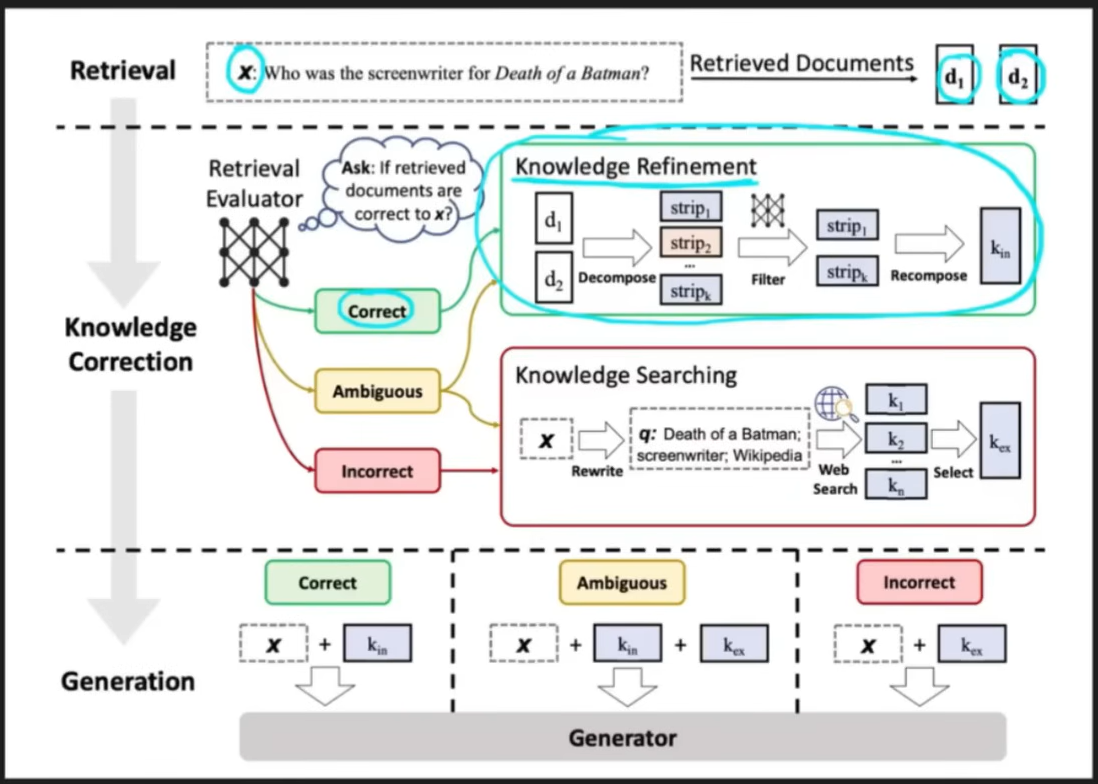

In [2]:
from typing import List, TypedDict
import re

from langchain_community.document_loaders import PyPDFLoader, TextLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
from dotenv import load_dotenv

load_dotenv()

C:\Users\dell\AppData\Local\Temp\ipykernel_10224\239751918.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader, TextLoader


True

In [3]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_groq import ChatGroq
from dotenv import load_dotenv

load_dotenv()

llm = ChatGroq(model='qwen/qwen3.8-27b', temperature=0)
embedding = GoogleGenerativeAIEmbeddings(model='gemini-embedding-001')    

In [4]:
# 1. just load the doc

docs = (
    TextLoader("../Document/doc.txt").load()
)

docs

[Document(metadata={'source': '../Document/doc.txt'}, page_content="# The Solar System\n\n## The Sun\n\nThe Sun is the star at the center of the Solar System. It contains about 99.86% of the Solar System's total mass. Its gravity keeps planets and other objects in orbit. The Sun's core reaches about 15 millionÂ°C.\n\n## Inner Planets\n\nThe four inner planets are Mercury, Venus, Earth, and Mars. They are terrestrial planets made mainly of rock and metal.\n\n**Mercury** is the smallest planet and closest to the Sun. It has almost no atmosphere and experiences extreme temperature changes.\n\n**Venus** is the hottest planet. Its thick carbon-dioxide atmosphere creates a strong greenhouse effect that traps heat.\n\n**Earth** is the third planet from the Sun and the only planet currently known to support life. It has abundant liquid water.\n\n**Mars** is called the Red Planet because of iron oxide on its surface. It contains Olympus Mons, the largest known volcano in the Solar System.\n\n##

In [5]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=400,
    chunk_overlap=50
)

chunks = text_splitter.split_documents(docs)

In [25]:
vector_store = FAISS.from_documents(chunks, embedding=embedding)
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 3})

In [6]:
# state for the Graph
class State(TypedDict):
    question: str
    docs: List[Document]

    strips: List[str]            # output of decomposition (sentence strips)
    kept_strips: List[str]       # after filtering (kept sentences)
    refined_context: str         # recomposed internal knowledge (joined kept_strips)

    answer: str

In [7]:
# retrival tool 
def retrieve(state:State):
    que = state['question']

    return {
        "docs":retriever.invoke(que)
    }

In [8]:
# now retrivel part is done now we have to check that all the doc is perfect or not

def decompose_to_sentences(text)->List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

In [9]:
# -----------------------------
# FILTER (LLM judge)
# -----------------------------

# like we make into the langchain 

class Output(BaseModel):
    keep : bool

prompt = ChatPromptTemplate.from_messages([
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

chain = prompt | llm.with_structured_output(Output)
# this will give the list of str that only needed

In [50]:
def refine(state:State)->State:
    '''get all the doc split and then feed to the judge and it will give use the onlystr that can use to generate the answer'''

    q = state['question']

    # Combine retrieved docs into one context string
    context = "\n\n".join(d.page_content for d in state["docs"]).strip()

    # 1) DECOMPOSITION: context -> sentence strips
    strips = decompose_to_sentences(context)

    # 2) FILTER: keep only relevant strips
    kept: List[str] = []

    for s in strips:
        if chain.invoke({"question": q, "sentence": s}).keep:
            kept.append(s)

    # 3) RECOMPOSE: glue kept strips back together (internal knowledge)
    refined_context = "\n".join(kept).strip()

    return {
        "strips":strips,
        "kept_strips":kept, 
        "refined_context":refined_context
    }


In [60]:
# the generate node

def generate(state:State):

    system_prompt = ChatPromptTemplate(
        [
            (
                "system",
                "You are a helpful ML tutor. Answer ONLY using the provided refined bullets.\n"
                "If the bullets are empty or insufficient, say: 'I don't know based on the provided books.'",
            ),
            ("human", "Question: {question}\n\nRefined context:\n{refined_context}"),
        ]
    )

    response = (system_prompt | llm).invoke({"question": state["question"], "refined_context": state['refined_context']})
    return {"answer": response.content}

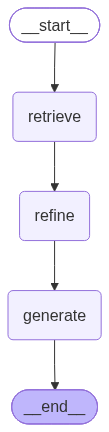

In [61]:
#make the graph

g = StateGraph(State)
g.add_node("retrieve", retrieve)
g.add_node("refine", refine)
g.add_node("generate", generate)

g.add_edge(START, "retrieve")
g.add_edge("retrieve", "refine")
g.add_edge("refine", "generate")
g.add_edge("generate", END)

app = g.compile()

app

In [62]:
res = app.invoke({
    "question": "what is the sun",
    "docs": [],
    "strips": [],
    "kept_strips": [],
    "refined_context": "",
    "answer": ""
})
print(res["answer"])

The Sun is a yellow dwarf star at the center of our solar system. It accounts for 99.86% of the total mass of the entire solar system, and its intense gravity keeps the planets, asteroids, and other objects in orbit around it. The Sun's core reaches temperatures of over 15 million degrees Celsius.


In [ ]:
res['docs'][1].page_content

"The Sun is a yellow dwarf star at the center of our solar system. It accounts for 99.86% of the total mass of the entire solar system. Its intense gravity keeps the planets, asteroids, and other objects in orbit around it. The Sun's core reaches temperatures of over 15 million degrees Celsius."

: 

In [67]:
res['strips']

['## The Sun The Sun is a yellow dwarf star at the center of our solar system.',
 'It accounts for 99.86% of the total mass of the entire solar system.',
 'Its intense gravity keeps the planets, asteroids, and other objects in orbit around it.',
 "The Sun's core reaches temperatures of over 15 million degrees Celsius.",
 '## Introduction The Solar System consists of our Sun and everything bound to it by gravity.',
 'This includes the eight official planets, dozens of dwarf planets, hundreds of moons, and millions of asteroids, comets, and meteoroids.',
 "It is located in the Milky Way galaxy's Orion-Cygnus arm."]

In [69]:
res['kept_strips']

['## The Sun The Sun is a yellow dwarf star at the center of our solar system.',
 'It accounts for 99.86% of the total mass of the entire solar system.',
 'Its intense gravity keeps the planets, asteroids, and other objects in orbit around it.',
 "The Sun's core reaches temperatures of over 15 million degrees Celsius.",
 '## Introduction The Solar System consists of our Sun and everything bound to it by gravity.',
 "It is located in the Milky Way galaxy's Orion-Cygnus arm."]

In [70]:
res['refined_context']

"## The Sun The Sun is a yellow dwarf star at the center of our solar system.\nIt accounts for 99.86% of the total mass of the entire solar system.\nIts intense gravity keeps the planets, asteroids, and other objects in orbit around it.\nThe Sun's core reaches temperatures of over 15 million degrees Celsius.\n## Introduction The Solar System consists of our Sun and everything bound to it by gravity.\nIt is located in the Milky Way galaxy's Orion-Cygnus arm."